# TS3 Ánalisis de Fourier: FFT, desparramo, interpolación y ventaneo 

## Introducción

En esta tarea se estudia el análisis de señales senoidales en el dominio de la frecuencia mediante la **Transformada Discreta de Fourier (DFT)**, calculada mediante la **FFT**.

El objetivo principal es analizar el fenómeno de **desparramo espectral** y observar cómo cambia el espectro de una señal dependiendo de la relación entre su frecuencia y los bins de la DFT. Para ello, se comparan tres señales senoidales de potencia normalizada con frecuencias muy próximas entre sí.

Además, se utiliza la **identidad de Parseval** para comprobar la conservación de la potencia entre el dominio temporal y frecuencial. Finalmente, se aplica la técnica de **zero padding**, añadiendo ceros a la señal original para obtener una representación más detallada del espectro y estudiar su efecto sobre la resolución de la FFT.

# A) Análisis del efecto de la desintonía en el espectro

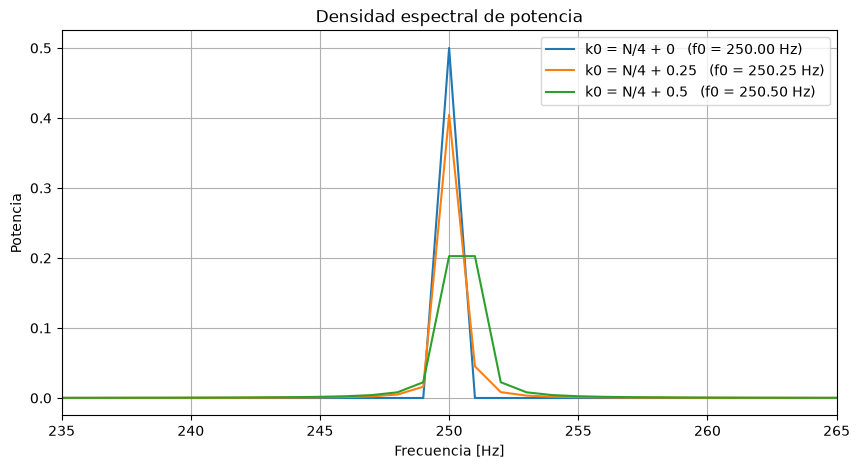

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.close('all')

fs = 1000
N = 1000
Vmax = np.sqrt(2)
dc = 0
ph = 0
delta_f = fs / N
k0_base = N/4
desintonias = [0, 0.25, 0.5]

def gen_sin(f0, Vmax=Vmax, dc=dc, ph=ph, nn=N, fs=fs):
    
        tt = np.arange(nn) / fs
    
        xx = dc + Vmax * np.sin(2 * np.pi * f0 * tt + ph)
        return tt, xx
    
N2 = N//2 

ff = np.arange(N2) * delta_f


plt.figure(figsize=(10, 5))

for desintonia in desintonias: 
    k0 = k0_base + desintonia
    f0 = k0 * delta_f
    tt, xx = gen_sin(Vmax=Vmax, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
    
    X = np.fft.fft(xx) 
    
    X_pos = X[:N2] 
    
    modulo = np.abs(X_pos) / N 

    potencia = modulo**2 

    plt.plot(
        ff,
        potencia,
        label=f'k0 = N/4 + {desintonia}   (f0 = {f0:.2f} Hz)'
    )

    
plt.title('Densidad espectral de potencia')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.grid(True)
plt.legend()

plt.xlim(k0_base * delta_f - 15,
         k0_base * delta_f + 15)

plt.show()

## B) Verificamos la potencia unitaraia de cada PSD usando la identidad de Parseval

In [2]:
for desintonia in desintonias:
    
    k0 = k0_base + desintonia
    f0 = k0 * delta_f
    
    tt, xx = gen_sin(f0, Vmax=Vmax, dc=dc, ph=ph, nn=N, fs=fs)
    
    X = np.fft.fft(xx)
    
    potencia_tiempo = np.mean(xx**2)
    
    potencia_frecuencia = np.sum(np.abs(X)**2) / N**2
    
    print('f0 =', f0, 'Hz')
    print('Potencia en tiempo =', potencia_tiempo)
    print('Potencia en frecuencia =', potencia_frecuencia)
    print()


f0 = 250.0 Hz
Potencia en tiempo = 1.0000000000000002
Potencia en frecuencia = 1.0000000000000002

f0 = 250.25 Hz
Potencia en tiempo = 0.9989999999999998
Potencia en frecuencia = 0.9989999999999996

f0 = 250.5 Hz
Potencia en tiempo = 1.0000000000000004
Potencia en frecuencia = 1.0000000000000007



### Discusión de los resultados

Aunque las frecuencias de las tres señales senoidales se diferencian muy poco, sus espectros son bastante distintos debido a la relación entre la frecuencia de la señal y los **bins de la DFT**.

En nuestro caso, la resolución frecuencial es:

$$
\Delta f = \frac{f_s}{N} = 1 \text{ Hz}
$$

Para $f_0 = 250$ Hz, la frecuencia coincide exactamente con uno de los bins de la DFT, por lo que la potencia se concentra en dicho bin.

En cambio, para $f_0 = 250.25$ Hz y $f_0 = 250.5$ Hz, la frecuencia se encuentra entre bins, por lo que aparece **desparramo espectral** y la potencia se distribuye entre varios de ellos. En el caso de $f_0 = 250.5$ Hz, la frecuencia se encuentra justo entre los bins de 250 Hz y 251 Hz, por lo que ambos presentan contribuciones similares.

A pesar de estas diferencias en la distribución de la potencia, mediante la **identidad de Parseval** comprobamos que la potencia total de las tres señales se mantiene aproximadamente unitaria.

## C) Repetimos el experimento mediante la técnica de zero padding

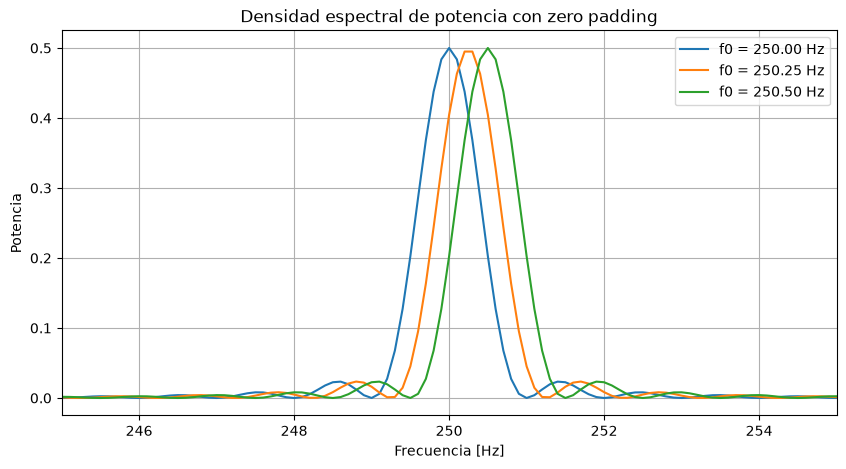

In [3]:
plt.figure(figsize=(10, 5))

for desintonia in desintonias:
    
    k0 = k0_base + desintonia
    f0 = k0 * delta_f
    
    tt, xx = gen_sin(Vmax=Vmax, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
    
    ceros = np.zeros(9 * N)
    
    xx_padding = np.concatenate((xx, ceros))
    
    N_padding = len(xx_padding)
    
    X_padding = np.fft.fft(xx_padding)
    
    N2_padding = N_padding // 2
    X_padding_pos = X_padding[:N2_padding]
    
    delta_f_padding = fs / N_padding
    
    ff_padding = np.arange(N2_padding) * delta_f_padding
    
    modulo_padding = np.abs(X_padding_pos) / N
    
    potencia_padding = modulo_padding**2
    
    plt.plot(
        ff_padding,
        potencia_padding,
        label=f'f0 = {f0:.2f} Hz'
    )


plt.title('Densidad espectral de potencia con zero padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.grid(True)
plt.legend()

plt.xlim(245, 255)

plt.show()

### Discusión de los resultados

Al aplicar *zero padding* se añaden $9N$ ceros al final de las $N$ muestras originales, por lo que la FFT pasa de tener 1000 a 10000 puntos. Como consecuencia, la separación entre los puntos de frecuencia pasa de:

$$
\Delta f = \frac{f_s}{N} = \frac{1000}{1000} = 1 \text{ Hz}
$$

a:

$$
\Delta f_{\text{padding}} = \frac{f_s}{10N} = \frac{1000}{10000} = 0.1 \text{ Hz}
$$

Esto permite representar el espectro con muchos más puntos y observar con mayor detalle su forma. En la gráfica se pueden distinguir mejor los máximos correspondientes a las señales de 250 Hz, 250.25 Hz y 250.5 Hz, además de la forma de los lóbulos principales y laterales.

Sin embargo, el *zero padding* no elimina el desparramo espectral ni añade información nueva a la señal, ya que las muestras originales siguen siendo las mismas y únicamente se han añadido ceros al final. Por tanto, se obtiene una representación más detallada e interpolada del espectro, pero no se mejora la resolución espectral real.

En conclusión, el *zero padding* permite visualizar mejor el espectro y localizar con mayor precisión sus máximos, pero no modifica la información contenida en la señal original.

## Conclusión

A lo largo de esta tarea se ha podido comprobar cómo la representación frecuencial de una señal depende de la relación entre su frecuencia y los bins de la DFT. Cuando la frecuencia de la senoidal coincide exactamente con un bin, su potencia aparece concentrada principalmente en dicho bin. En cambio, cuando la frecuencia se encuentra entre bins, aparece el fenómeno de **desparramo espectral**, distribuyéndose la potencia entre diferentes frecuencias.

Mediante la **identidad de Parseval** se comprobó que, aunque la distribución de la potencia en el espectro sea diferente para las tres señales, la potencia total calculada en el dominio temporal y en el dominio frecuencial coincide y se mantiene aproximadamente unitaria.

Por último, mediante la técnica de **zero padding** se consiguió reducir la separación entre los puntos de la FFT de 1 Hz a 0.1 Hz, obteniendo una representación mucho más detallada del espectro. Esto permitió visualizar mejor los máximos y los lóbulos del espectro, aunque sin eliminar el desparramo espectral ni añadir nueva información a la señal original.

En conjunto, la tarea permite comprender mejor la relación entre la duración de la señal, los bins de la DFT, el desparramo espectral y la representación de una señal en el dominio de la frecuencia.